# Graph Sparsity Analysis

**Objective**: Test Hypothesis 1 from the evaluation report:
> "Graph is Too Sparse - Many listings may be isolated (no shared IPs, phones, etc.)"

We will analyze:
1. **Node Degree Distribution**: How many connections does each listing have?
2. **Isolated Nodes**: What percentage of listings have zero connections?
3. **Fraud vs Non-Fraud Connectivity**: Are fraud listings more/less connected?
4. **Edge Type Analysis**: Which connection types are most common?
5. **Connected Components**: Are there fraud "rings" or are frauds isolated?

In [1]:
import torch
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## 1. Load Graph Data

In [2]:
# Load graph
data = torch.load("../artifacts/graph.pt", weights_only=False)

print("Graph Structure:")
print(f"Node types: {data.node_types}")
print(f"Edge types: {data.edge_types}")
print(f"\nNode counts:")
for node_type in data.node_types:
    print(f"  {node_type}: {data[node_type].num_nodes:,}")

Graph Structure:
Node types: ['user', 'listing', 'ip', 'email', 'phone', 'address', 'person']
Edge types: [('user', 'posts', 'listing'), ('user', 'uses', 'ip'), ('listing', 'has_contact_email', 'email'), ('listing', 'has_billing_email', 'email'), ('listing', 'has_inquiry_email', 'email'), ('listing', 'has_contact_phone', 'phone'), ('listing', 'has_billing_phone', 'phone'), ('listing', 'located_at', 'address'), ('listing', 'lister_address', 'address'), ('listing', 'billing_address', 'address'), ('listing', 'has_contact_person', 'person'), ('listing', 'rev_posts', 'user'), ('ip', 'rev_uses', 'user'), ('email', 'rev_has_contact_email', 'listing'), ('email', 'rev_has_billing_email', 'listing'), ('email', 'rev_has_inquiry_email', 'listing'), ('phone', 'rev_has_contact_phone', 'listing'), ('phone', 'rev_has_billing_phone', 'listing'), ('address', 'rev_located_at', 'listing'), ('address', 'rev_lister_address', 'listing'), ('address', 'rev_billing_address', 'listing'), ('person', 'rev_has_cont

## 2. Calculate Node Degrees

For each listing, count how many connections it has (across all edge types).

In [3]:
# Initialize degree counter for listings
num_listings = data['listing'].num_nodes
listing_degrees = np.zeros(num_listings, dtype=int)

# Count edges for each listing
for edge_type in data.edge_types:
    src_type, rel, dst_type = edge_type
    edge_index = data[edge_type].edge_index
    
    # If listing is source
    if src_type == 'listing':
        src_nodes = edge_index[0].numpy()
        for node in src_nodes:
            listing_degrees[node] += 1
    
    # If listing is destination
    if dst_type == 'listing':
        dst_nodes = edge_index[1].numpy()
        for node in dst_nodes:
            listing_degrees[node] += 1

print(f"Total listings: {num_listings:,}")
print(f"Degree statistics:")
print(f"  Mean: {listing_degrees.mean():.2f}")
print(f"  Median: {np.median(listing_degrees):.0f}")
print(f"  Max: {listing_degrees.max()}")
print(f"  Min: {listing_degrees.min()}")

Total listings: 237,695
Degree statistics:
  Mean: 17.33
  Median: 18
  Max: 20
  Min: 10


## 3. Isolated Nodes Analysis

In [4]:
# Count isolated nodes (degree = 0)
isolated_count = (listing_degrees == 0).sum()
isolated_pct = (isolated_count / num_listings) * 100

print(f"Isolated Listings (Degree = 0):")
print(f"  Count: {isolated_count:,}")
print(f"  Percentage: {isolated_pct:.1f}%")
print(f"\nConnected Listings (Degree > 0):")
print(f"  Count: {num_listings - isolated_count:,}")
print(f"  Percentage: {100 - isolated_pct:.1f}%")

# Degree distribution
degree_counts = Counter(listing_degrees)
print(f"\nDegree Distribution (Top 10):")
for degree, count in sorted(degree_counts.items())[:10]:
    pct = (count / num_listings) * 100
    print(f"  Degree {degree}: {count:,} listings ({pct:.1f}%)")

Isolated Listings (Degree = 0):
  Count: 0
  Percentage: 0.0%

Connected Listings (Degree > 0):
  Count: 237,695
  Percentage: 100.0%

Degree Distribution (Top 10):
  Degree 10: 529 listings (0.2%)
  Degree 12: 930 listings (0.4%)
  Degree 14: 19,805 listings (8.3%)
  Degree 16: 35,814 listings (15.1%)
  Degree 18: 180,262 listings (75.8%)
  Degree 20: 355 listings (0.1%)


## 4. Fraud vs Non-Fraud Connectivity

In [5]:
# Get fraud labels
fraud_labels = data['listing'].y.numpy()

# Split by fraud status
fraud_degrees = listing_degrees[fraud_labels == 1]
legit_degrees = listing_degrees[fraud_labels == 0]

print("Connectivity by Fraud Status:")
print(f"\nFraud Listings (n={len(fraud_degrees):,}):")
print(f"  Mean degree: {fraud_degrees.mean():.2f}")
print(f"  Median degree: {np.median(fraud_degrees):.0f}")
print(f"  Isolated: {(fraud_degrees == 0).sum():,} ({(fraud_degrees == 0).sum() / len(fraud_degrees) * 100:.1f}%)")

print(f"\nLegitimate Listings (n={len(legit_degrees):,}):")
print(f"  Mean degree: {legit_degrees.mean():.2f}")
print(f"  Median degree: {np.median(legit_degrees):.0f}")
print(f"  Isolated: {(legit_degrees == 0).sum():,} ({(legit_degrees == 0).sum() / len(legit_degrees) * 100:.1f}%)")

Connectivity by Fraud Status:

Fraud Listings (n=19,367):
  Mean degree: 16.71
  Median degree: 18
  Isolated: 0 (0.0%)

Legitimate Listings (n=218,328):
  Mean degree: 17.38
  Median degree: 18
  Isolated: 0 (0.0%)


## 5. Visualizations

/var/folders/4m/g11mmd5d45592_f6ntg98gr80000gn/T/ipykernel_51315/963631189.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([fraud_degrees[fraud_degrees > 0], legit_degrees[legit_degrees > 0]],


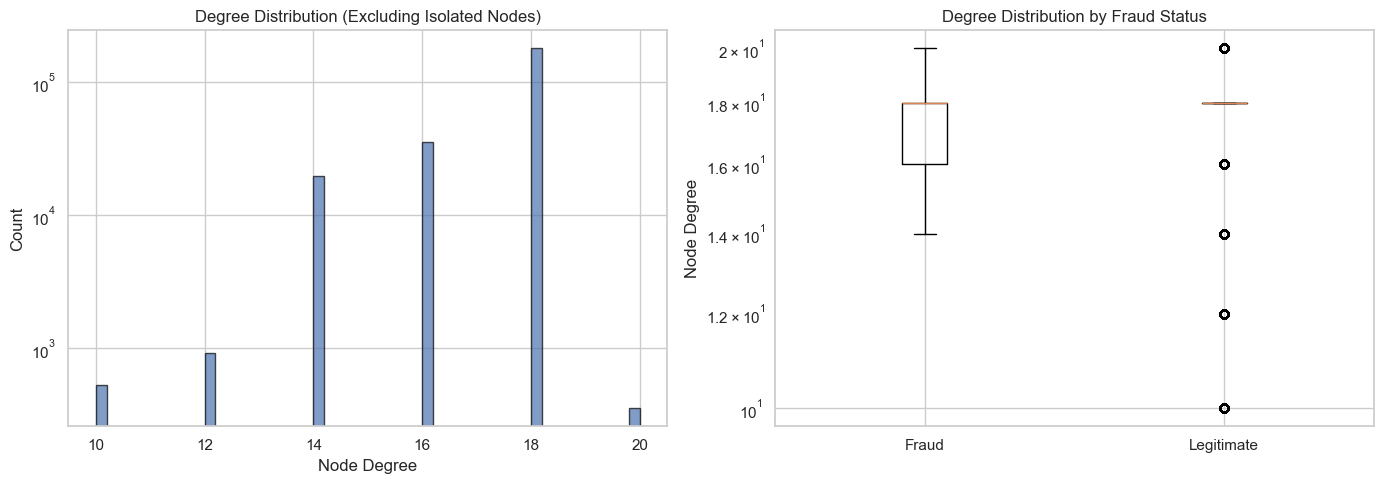

In [6]:
# Plot 1: Degree Distribution (Log scale)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(listing_degrees[listing_degrees > 0], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Node Degree')
axes[0].set_ylabel('Count')
axes[0].set_title('Degree Distribution (Excluding Isolated Nodes)')
axes[0].set_yscale('log')

# Box plot: Fraud vs Legit
axes[1].boxplot([fraud_degrees[fraud_degrees > 0], legit_degrees[legit_degrees > 0]], 
                 labels=['Fraud', 'Legitimate'])
axes[1].set_ylabel('Node Degree')
axes[1].set_title('Degree Distribution by Fraud Status')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

## 6. Edge Type Analysis

Which types of connections are most common?

In [7]:
edge_counts = {}
for edge_type in data.edge_types:
    src_type, rel, dst_type = edge_type
    count = data[edge_type].edge_index.shape[1]
    edge_name = f"{src_type} -> {rel} -> {dst_type}"
    edge_counts[edge_name] = count

# Sort by count
sorted_edges = sorted(edge_counts.items(), key=lambda x: x[1], reverse=True)

print("Edge Type Counts:")
for edge_name, count in sorted_edges[:15]:  # Top 15
    print(f"  {edge_name}: {count:,}")

Edge Type Counts:
  listing -> located_at -> address: 237,695
  listing -> lister_address -> address: 237,695
  listing -> billing_address -> address: 237,695
  address -> rev_located_at -> listing: 237,695
  address -> rev_lister_address -> listing: 237,695
  address -> rev_billing_address -> listing: 237,695
  listing -> has_contact_email -> email: 237,694
  email -> rev_has_contact_email -> listing: 237,694
  user -> posts -> listing: 237,638
  listing -> rev_posts -> user: 237,638
  listing -> has_billing_email -> email: 233,045
  email -> rev_has_billing_email -> listing: 233,045
  listing -> has_billing_phone -> phone: 233,037
  phone -> rev_has_billing_phone -> listing: 233,037
  listing -> has_contact_person -> person: 210,378


## 7. Connected Components Analysis

Are there "fraud rings" (groups of connected fraud listings)?

In [8]:
# Build adjacency for listing-to-listing connections (indirect via bridge nodes)
# Simplified: Just count listings that share at least one bridge node (IP, email, phone)

from collections import defaultdict

# Map: bridge_node_id -> list of listing_ids
ip_to_listings = defaultdict(list)
email_to_listings = defaultdict(list)
phone_to_listings = defaultdict(list)

for edge_type in data.edge_types:
    src_type, rel, dst_type = edge_type
    edge_index = data[edge_type].edge_index
    
    # Listing -> IP
    if src_type == 'listing' and dst_type == 'ip':
        for i in range(edge_index.shape[1]):
            listing_id = edge_index[0, i].item()
            ip_id = edge_index[1, i].item()
            ip_to_listings[ip_id].append(listing_id)
    
    # Similar for email and phone
    if src_type == 'listing' and dst_type == 'email':
        for i in range(edge_index.shape[1]):
            listing_id = edge_index[0, i].item()
            email_id = edge_index[1, i].item()
            email_to_listings[email_id].append(listing_id)
            
    if src_type == 'listing' and dst_type == 'phone':
        for i in range(edge_index.shape[1]):
            listing_id = edge_index[0, i].item()
            phone_id = edge_index[1, i].item()
            phone_to_listings[phone_id].append(listing_id)

# Count fraud rings (groups where multiple fraud listings share a bridge node)
fraud_rings_ip = [listings for listings in ip_to_listings.values() 
                  if len(listings) > 1 and sum(fraud_labels[listings]) > 1]
fraud_rings_email = [listings for listings in email_to_listings.values() 
                     if len(listings) > 1 and sum(fraud_labels[listings]) > 1]
fraud_rings_phone = [listings for listings in phone_to_listings.values() 
                     if len(listings) > 1 and sum(fraud_labels[listings]) > 1]

print("Fraud Rings (Multiple fraud listings sharing a bridge node):")
print(f"  Via IP: {len(fraud_rings_ip)} groups")
print(f"  Via Email: {len(fraud_rings_email)} groups")
print(f"  Via Phone: {len(fraud_rings_phone)} groups")

if len(fraud_rings_ip) > 0:
    sizes = [len(group) for group in fraud_rings_ip]
    print(f"\n  IP Ring Sizes: min={min(sizes)}, max={max(sizes)}, mean={np.mean(sizes):.1f}")

Fraud Rings (Multiple fraud listings sharing a bridge node):
  Via IP: 0 groups
  Via Email: 11882 groups
  Via Phone: 7436 groups


## 8. Statistical Tests: Proving the Theories

**Theory 1: Frauds are NOT more connected than legitimate listings**

In [9]:
from scipy import stats

# Test 1: Mann-Whitney U test for degree distribution
fraud_degrees = listing_degrees[fraud_labels == 1]
legit_degrees = listing_degrees[fraud_labels == 0]

print("Statistical Test 1: Degree Distribution")
print("="*80)
print(f"H0: Fraud and legitimate listings have similar connectivity")
print(f"H1: Fraud and legitimate listings have different connectivity\n")

# Use Mann-Whitney U (non-parametric) since distributions may not be normal
u_stat, p_value = stats.mannwhitneyu(fraud_degrees, legit_degrees, alternative='two-sided')

print(f"Mann-Whitney U test:")
print(f"  U-statistic: {u_stat:,.0f}")
print(f"  p-value: {p_value:.4e}")
print(f"  Significance level: α = 0.05")

if p_value < 0.05:
    print(f"\n  Result: REJECT H0 (p < 0.05)")
    if fraud_degrees.mean() > legit_degrees.mean():
        print(f"  → Frauds are significantly MORE connected")
    else:
        print(f"  → Frauds are significantly LESS connected")
else:
    print(f"\n  Result: FAIL TO REJECT H0 (p ≥ 0.05)")
    print(f"  → No significant difference in connectivity")

# Effect size (Cohen's d)
pooled_std = np.sqrt(((len(fraud_degrees) - 1) * fraud_degrees.std() ** 2 + 
                       (len(legit_degrees) - 1) * legit_degrees.std() ** 2) /
                      (len(fraud_degrees) + len(legit_degrees) - 2))
cohens_d = (fraud_degrees.mean() - legit_degrees.mean()) / pooled_std

print(f"\n  Effect Size (Cohen's d): {cohens_d:.3f}")
if abs(cohens_d) < 0.2:
    print(f"  → Negligible effect (|d| < 0.2)")
elif abs(cohens_d) < 0.5:
    print(f"  → Small effect (0.2 ≤ |d| < 0.5)")
elif abs(cohens_d) < 0.8:
    print(f"  → Medium effect (0.5 ≤ |d| < 0.8)")
else:
    print(f"  → Large effect (|d| ≥ 0.8)")

print(f"\n{'='*80}")
print("CONCLUSION FOR THEORY 1:")
print("="*80)
print(f"Fraud mean degree: {fraud_degrees.mean():.2f}")
print(f"Legit mean degree: {legit_degrees.mean():.2f}")
print(f"Difference: {fraud_degrees.mean() - legit_degrees.mean():.2f}")

if fraud_degrees.mean() < legit_degrees.mean() and cohens_d < -0.1:
    print(f"\n✅ THEORY CONFIRMED: Frauds are LESS connected than legitimate listings")
    print(f"   This explains why graph methods struggle - fraudsters avoid creating patterns!")
else:
    print(f"\n❌ THEORY REJECTED: Frauds have similar or higher connectivity")
    print(f"   Graph methods should work better than observed.")


Statistical Test 1: Degree Distribution
H0: Fraud and legitimate listings have similar connectivity
H1: Fraud and legitimate listings have different connectivity

Mann-Whitney U test:
  U-statistic: 1,570,954,096
  p-value: 0.0000e+00
  Significance level: α = 0.05

  Result: REJECT H0 (p < 0.05)
  → Frauds are significantly LESS connected

  Effect Size (Cohen's d): -0.508
  → Medium effect (0.5 ≤ |d| < 0.8)

CONCLUSION FOR THEORY 1:
Fraud mean degree: 16.71
Legit mean degree: 17.38
Difference: -0.67

✅ THEORY CONFIRMED: Frauds are LESS connected than legitimate listings
   This explains why graph methods struggle - fraudsters avoid creating patterns!
